# 🤖 Body Performance Dataset — Model Training & Tuning
**File 4 of 5 | Diploma Project**

---

## 🎯 Objective
Train **6 machine learning classifiers** using `RandomizedSearchCV` with
5-fold stratified cross-validation across **3 different train/test split ratios**
to measure how split size affects model accuracy and generalisation.

## 🛡️ Anti-Leakage Strategy
- ALL scaling/preprocessing lives **inside** sklearn `Pipeline` objects
- Scalers are fitted **only on the training fold** — never on test data
- `StratifiedKFold` preserves class ratios in every fold
- Each trial's test set is held out completely and never touched during tuning

## 🔀 Three Trials
| Trial | Train | Test | Train rows | Test rows |
|-------|-------|------|------------|-----------|
| **Trial 1** | 80 % | 20 % | ~10,630 | ~2,658 |
| **Trial 2** | 70 % | 30 % | ~9,302 | ~3,986 |
| **Trial 3** | 50 % | 50 % | ~6,644 | ~6,644 |

> **Why test different splits?**  
> A 50:50 split uses less training data → models may underfit.  
> An 80:20 split maximises training data → usually best accuracy.  
> Comparing all three shows how **data-hungry** each algorithm is.

## 📋 Models Trained in Every Trial
| # | Model | Scaler | Key Strength |
|---|-------|--------|-------------|
| 1 | K-Nearest Neighbours (KNN) | StandardScaler | Non-parametric baseline |
| 2 | Logistic Regression (LR) | StandardScaler | Linear, interpretable |
| 3 | Decision Tree (DT) | None (passthrough) | Visualisable, non-linear |
| 4 | Support Vector Machine (SVM) | RobustScaler | Max-margin, RBF kernel |
| 5 | Neural Network (MLP) | StandardScaler | Learns complex interactions |
| 6 | Random Forest (RF) | None (passthrough) | Ensemble, high accuracy |


## 🔧 Section 1 — Imports & Global Configuration

In [1]:
import pandas as pd
import numpy as np
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection   import (train_test_split, RandomizedSearchCV,
                                        StratifiedKFold, cross_val_score)
from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler, RobustScaler
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from sklearn.svm               import SVC
from sklearn.neural_network    import MLPClassifier
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (accuracy_score, f1_score,
                                        classification_report,
                                        confusion_matrix, ConfusionMatrixDisplay)
from scipy.stats               import randint, loguniform

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid", font_scale=1.05)

# ── Global CV & Search config (shared across all trials)
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_ITER  = 20      # random parameter combinations per model
SCORING = "accuracy"

print("✅ Libraries loaded")
print(f"   CV strategy : StratifiedKFold  k=5, shuffle=True, seed=42")
print(f"   n_iter      : {N_ITER}  (RandomizedSearchCV combinations)")
print(f"   Scoring     : {SCORING}")


✅ Libraries loaded
   CV strategy : StratifiedKFold  k=5, shuffle=True, seed=42
   n_iter      : 20  (RandomizedSearchCV combinations)
   Scoring     : accuracy


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📥 Section 2 — Load Engineered Dataset
Load `data_engineered.csv` (output of `03_Feature_Engineering.ipynb`).
Drop the `class_label` helper column if present — it is a string duplicate
of the numeric `class` column and must not be used as a feature.

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Digilians/introduction to AI and Machine learning/final project/Data Cleaned.csv")
df = df.drop(columns=[c for c in ["class_label"] if c in df.columns])

X = df.drop(columns=["class"])
y = df["class"]

print(f"Dataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Features (X)   : {X.shape[1]} columns")
print(f"Target  (y)    : 'class'  — values {sorted(y.unique())}")
print(f"\nClass distribution:")
label_map = {0: "1=D (Worst)", 1: "2=C", 2: "3=B", 3: "4=A (Best)"}
for cls, n in y.value_counts().sort_index().items():
    print(f"  {label_map[cls]:<18}  {n:,}  ({n/len(y)*100:.1f}%)")

Dataset shape  : 13,288 rows × 13 columns
Features (X)   : 12 columns
Target  (y)    : 'class'  — values [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Class distribution:
  1=D (Worst)         3,287  (24.7%)
  2=C                 3,337  (25.1%)
  3=B                 3,333  (25.1%)
  4=A (Best)          3,331  (25.1%)


## 🔁 Section 3 — Reusable Training Helper
`train_model()` wraps `RandomizedSearchCV` for any Pipeline.
It is called once per model per trial, keeping the code DRY.

In [4]:
def train_model(name, pipeline, param_dist, X_tr, y_tr, n_iter=N_ITER):
    """
    Fit RandomizedSearchCV on a Pipeline and return the best estimator.

    Parameters
    ----------
    name       : str   — display name for logging
    pipeline   : Pipeline — sklearn Pipeline with scaler + classifier
    param_dist : dict  — hyperparameter search space
    X_tr, y_tr : training data for this trial
    n_iter     : int   — number of random parameter combinations to try

    Returns
    -------
    best_estimator : fitted Pipeline (best params, refitted on full X_tr)
    result_dict    : dict with model name, best CV accuracy, time, params
    """
    t0 = time.time()

    search = RandomizedSearchCV(
        estimator           = pipeline,
        param_distributions = param_dist,
        n_iter              = n_iter,
        cv                  = CV,           # StratifiedKFold defined globally
        scoring             = SCORING,
        refit               = True,         # refit on full training set
        n_jobs              = -1,           # use all CPU cores
        random_state        = 42,
        verbose             = 0,
    )
    search.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    print(f"  {name:<16}  CV={search.best_score_:.4f}  t={elapsed:.1f}s")

    return search.best_estimator_, {
        "model"       : name,
        "cv_accuracy" : search.best_score_,
        "train_time_s": round(elapsed, 1),
        "best_params" : str(search.best_params_),
    }

print("✅ train_model() helper defined")


✅ train_model() helper defined


## ⚙️ Section 4 — Model Pipelines & Hyperparameter Search Spaces
All 6 pipelines and their search spaces are defined **once** here and
reused across all three trials.

### Why use a Pipeline?
A Pipeline chains the scaler and classifier into a single object.
When `RandomizedSearchCV` creates a CV fold, the scaler is fitted **only
on the training portion of that fold** — the validation data is transformed
but never used to fit the scaler. This is the correct way to avoid data leakage.

### Scaler choices
| Model | Scaler | Reason |
|-------|--------|--------|
| KNN | StandardScaler | Distance-based — scale is critical |
| Logistic Reg | StandardScaler | Gradient converges faster when scaled |
| Decision Tree | passthrough | Splits are threshold-based — scale irrelevant |
| SVM | RobustScaler | Handles residual outliers better |
| Neural Net | StandardScaler | Backprop needs zero-mean, unit-variance input |
| Random Forest | passthrough | Tree splits — scale irrelevant |


In [5]:
# ────────────────────────────────────────────────────────────────────────
# 1. K-Nearest Neighbours
# Classifies by majority vote of k nearest training neighbours.
# All features must be on the same scale (StandardScaler).
# ────────────────────────────────────────────────────────────────────────
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    KNeighborsClassifier()),
])
knn_params = {
    "clf__n_neighbors" : randint(3, 30),              # number of neighbours k
    "clf__weights"     : ["uniform", "distance"],     # equal vs proximity-weighted
    "clf__metric"      : ["euclidean", "manhattan"],  # distance measure
}

# ────────────────────────────────────────────────────────────────────────
# 2. Logistic Regression
# Linear model — softmax over 4 classes.
# C = inverse regularisation strength (small C = stronger penalty).
# ────────────────────────────────────────────────────────────────────────
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=2000, random_state=42)),
])
lr_params = {
    "clf__C"      : loguniform(0.001, 100),  # regularisation strength
    "clf__solver" : ["lbfgs", "saga"],       # optimisation algorithm
    "clf__penalty": ["l2"],                  # L2 (ridge) regularisation
}

# ────────────────────────────────────────────────────────────────────────
# 3. Decision Tree
# Recursive binary splitting on feature thresholds.
# No scaling needed — splits are rank-based, not distance-based.
# ────────────────────────────────────────────────────────────────────────
dt_pipe = Pipeline([
    ("scaler", "passthrough"),
    ("clf",    DecisionTreeClassifier(random_state=42)),
])
dt_params = {
    "clf__max_depth"         : randint(3, 25),         # tree depth limit
    "clf__min_samples_split" : randint(2, 30),         # min samples to split node
    "clf__min_samples_leaf"  : randint(1, 20),         # min samples in leaf
    "clf__criterion"         : ["gini", "entropy"],   # split quality measure
    "clf__max_features"      : ["sqrt", "log2", None], # features considered per split
}

# ────────────────────────────────────────────────────────────────────────
# 4. Support Vector Machine  (RBF kernel)
# Finds maximum-margin hyperplane; RBF kernel enables non-linear boundaries.
# RobustScaler is used to handle any residual outliers.
# ────────────────────────────────────────────────────────────────────────
svm_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf",    SVC(probability=True, random_state=42)),
])
svm_params = {
    "clf__C"      : loguniform(0.1, 100),   # margin softness
    "clf__kernel" : ["rbf", "linear"],      # kernel type
    "clf__gamma"  : ["scale", "auto"],       # RBF kernel width
}

# ────────────────────────────────────────────────────────────────────────
# 5. Neural Network  (MLP — Multi-Layer Perceptron)
# Feed-forward network; learns non-linear feature combinations via backprop.
# Early stopping prevents overfitting during training.
# ────────────────────────────────────────────────────────────────────────
# 1. Increase cache_size to 1000MB or 2000MB (depending on your RAM)
# 2. Set probability=False for a massive speed boost

mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    MLPClassifier(max_iter=500, random_state=42,
                              early_stopping=True, validation_fraction=0.1,
                              n_iter_no_change=15)),
])
mlp_params = {
    "clf__hidden_layer_sizes" : [(64,), (128,), (64, 32), (128, 64), (100, 50)],
    "clf__activation"         : ["relu", "tanh"],
    "clf__alpha"              : loguniform(1e-5, 0.1),    # L2 weight penalty
    "clf__learning_rate_init" : loguniform(1e-4, 0.01),  # Adam step size
}
# ────────────────────────────────────────────────────────────────────────
# 6. Random Forest
# Ensemble of decorrelated decision trees (bootstrap + random feature subsets).
# No scaling needed. n_jobs=-1 uses all CPU cores.
# ────────────────────────────────────────────────────────────────────────
rf_pipe = Pipeline([
    ("scaler", "passthrough"),
    ("clf",    RandomForestClassifier(random_state=42, n_jobs=-1)),
])
rf_params = {
    "clf__n_estimators"      : randint(100, 500),         # number of trees
    "clf__max_depth"         : [None] + list(range(5, 30, 3)),
    "clf__min_samples_split" : randint(2, 20),
    "clf__min_samples_leaf"  : randint(1, 10),
    "clf__max_features"      : ["sqrt", "log2", 0.5],
}

print("✅ All 6 pipelines and search spaces defined")
print("   Ready to run 3 split trials.")


✅ All 6 pipelines and search spaces defined
   Ready to run 3 split trials.


---
# 🟢 Trial 1 — 80:20 Split  (80 % Train / 20 % Test)

**Purpose:** Train all 6 models on 80 % of the data and evaluate on the
remaining 20 %.

> ✅ Maximum training data — expected highest accuracy.


## 📂 Trial 1 — Step 1: Create the 80:20 Split

In [6]:
# ── Create the 80:20 train/test split
# stratify=y ensures each class has the same proportion in both sets
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X, y,
    test_size   = 0.2,    # 20% test
    random_state= 42,             # fixed seed for reproducibility
    stratify    = y               # preserve class ratios
)

print(f"Trial 1 — 80:20 Split")
print(f"  Training rows : {X_train_1.shape[0]:,}  ({X_train_1.shape[0]/len(X)*100:.1f}%)")
print(f"  Test rows     : {X_test_1.shape[0]:,}  ({X_test_1.shape[0]/len(X)*100:.1f}%)")
print(f"  Features      : {X_train_1.shape[1]}")
print()
print("  Class distribution in training set:")
for cls, n in y_train_1.value_counts().sort_index().items():
    print(f"    class {cls}: {n:,}  ({n/len(y_train_1)*100:.1f}%)")

# Save splits
X_train_1.to_csv("X_train_t1.csv", index=False)
X_test_1.to_csv("X_test_t1.csv",   index=False)
y_train_1.to_csv("y_train_t1.csv", index=False)
y_test_1.to_csv("y_test_t1.csv",   index=False)
print("\n✅ Split CSVs saved (X_train_t1.csv, X_test_t1.csv, ...)")


Trial 1 — 80:20 Split
  Training rows : 10,630  (80.0%)
  Test rows     : 2,658  (20.0%)
  Features      : 12

  Class distribution in training set:
    class 0: 2,630  (24.7%)
    class 1: 2,669  (25.1%)
    class 2: 2,666  (25.1%)
    class 3: 2,665  (25.1%)

✅ Split CSVs saved (X_train_t1.csv, X_test_t1.csv, ...)


## 🤖 Trial 1 — Step 2: Train All 6 Models

In [7]:
print("="*60)
print(f"  TRIAL 1: 80:20 SPLIT — Training 6 Models")
print("="*60)
print(f"  {'Model':<16}  {'Best CV Acc':>12}  {'Time':>8}")
print("  " + "─"*42)

# ── Run RandomizedSearchCV for each model
knn_best_1,  knn_res_1  = train_model("KNN",          knn_pipe,  knn_params,  X_train_1, y_train_1)
lr_best_1,   lr_res_1   = train_model("LogisticReg",  lr_pipe,   lr_params,   X_train_1, y_train_1)
dt_best_1,   dt_res_1   = train_model("DecisionTree", dt_pipe,   dt_params,   X_train_1, y_train_1)
svm_best_1,  svm_res_1  = train_model("SVM",          svm_pipe,  svm_params,  X_train_1, y_train_1, n_iter=15)
mlp_best_1,  mlp_res_1  = train_model("NeuralNetwork",mlp_pipe,  mlp_params,  X_train_1, y_train_1)
rf_best_1,   rf_res_1   = train_model("RandomForest", rf_pipe,   rf_params,   X_train_1, y_train_1)

print("  " + "─"*42)
print("  ✅ All 6 models trained for Trial 1")


  TRIAL 1: 80:20 SPLIT — Training 6 Models
  Model              Best CV Acc      Time
  ──────────────────────────────────────────
  KNN               CV=0.6332  t=31.4s
  LogisticReg       CV=0.6166  t=14.9s
  DecisionTree      CV=0.6711  t=2.8s
  SVM               CV=0.7069  t=1157.0s
  NeuralNetwork     CV=0.7344  t=607.4s
  RandomForest      CV=0.7360  t=525.6s
  ──────────────────────────────────────────
  ✅ All 6 models trained for Trial 1


## 📊 Trial 1 — Step 3: Test-Set Evaluation

In [8]:
# ── Collect all models for this trial
models_t1 = {
    "KNN"          : knn_best_1,
    "LogisticReg"  : lr_best_1,
    "DecisionTree" : dt_best_1,
    "SVM"          : svm_best_1,
    "NeuralNetwork": mlp_best_1,
    "RandomForest" : rf_best_1,
}

results_t1 = []
print(f"Trial 1 (80:20) — Test-Set Results:")
print(f"  {'Model':<16} {'CV Acc':>8} {'Test Acc':>10} {'F1 Mac':>8} {'F1 Wt':>8}")
print("  " + "─"*56)

for mname, model in models_t1.items():
    y_pred  = model.predict(X_test_1)
    cv_res  = [r for r in [knn_res_1, lr_res_1, dt_res_1,
                            svm_res_1, mlp_res_1, rf_res_1]
               if r["model"] == mname][0]
    test_acc = accuracy_score(y_test_1, y_pred)
    f1_mac   = f1_score(y_test_1, y_pred, average="macro",    zero_division=0)
    f1_wt    = f1_score(y_test_1, y_pred, average="weighted", zero_division=0)

    print(f"  {mname:<16} {cv_res['cv_accuracy']:>8.4f} {test_acc:>10.4f} {f1_mac:>8.4f} {f1_wt:>8.4f}")
    results_t1.append({
        "model"       : mname,
        "split"       : "80:20",
        "cv_accuracy" : cv_res["cv_accuracy"],
        "test_accuracy": test_acc,
        "f1_macro"    : f1_mac,
        "f1_weighted" : f1_wt,
        "best_params" : cv_res["best_params"],
    })

# Sort by test accuracy
results_t1 = sorted(results_t1, key=lambda x: x["test_accuracy"], reverse=True)
best_t1 = results_t1[0]
print()
print(f"  🏆 Best model (Trial 1) : {best_t1['model']}  →  Test Acc = {best_t1['test_accuracy']:.4f}")


Trial 1 (80:20) — Test-Set Results:
  Model              CV Acc   Test Acc   F1 Mac    F1 Wt
  ────────────────────────────────────────────────────────
  KNN                0.6332     0.6381   0.6399   0.6393
  LogisticReg        0.6166     0.6204   0.6188   0.6181
  DecisionTree       0.6711     0.6806   0.6826   0.6820
  SVM                0.7069     0.7193   0.7189   0.7184
  NeuralNetwork      0.7344     0.7592   0.7592   0.7588
  RandomForest       0.7360     0.7532   0.7547   0.7543

  🏆 Best model (Trial 1) : NeuralNetwork  →  Test Acc = 0.7592


### Trial 1 — Detailed Classification Report (Best Model)

In [9]:
# Full per-class breakdown for the best model in this trial
best_model_t1 = models_t1[best_t1["model"]]
y_pred_best_1 = best_model_t1.predict(X_test_1)

print(f"Classification Report — {best_t1['model']}  (80:20 split)")
print(classification_report(
    y_test_1, y_pred_best_1,
    target_names=["Class 1 (D-Worst)", "Class 2 (C)", "Class 3 (B)", "Class 4 (A-Best)"],
    zero_division=0
))


Classification Report — NeuralNetwork  (80:20 split)
                   precision    recall  f1-score   support

Class 1 (D-Worst)       0.92      0.83      0.87       657
      Class 2 (C)       0.77      0.66      0.71       668
      Class 3 (B)       0.64      0.66      0.65       667
 Class 4 (A-Best)       0.73      0.90      0.81       666

         accuracy                           0.76      2658
        macro avg       0.77      0.76      0.76      2658
     weighted avg       0.77      0.76      0.76      2658



### Trial 1 — Confusion Matrix (Best Model)

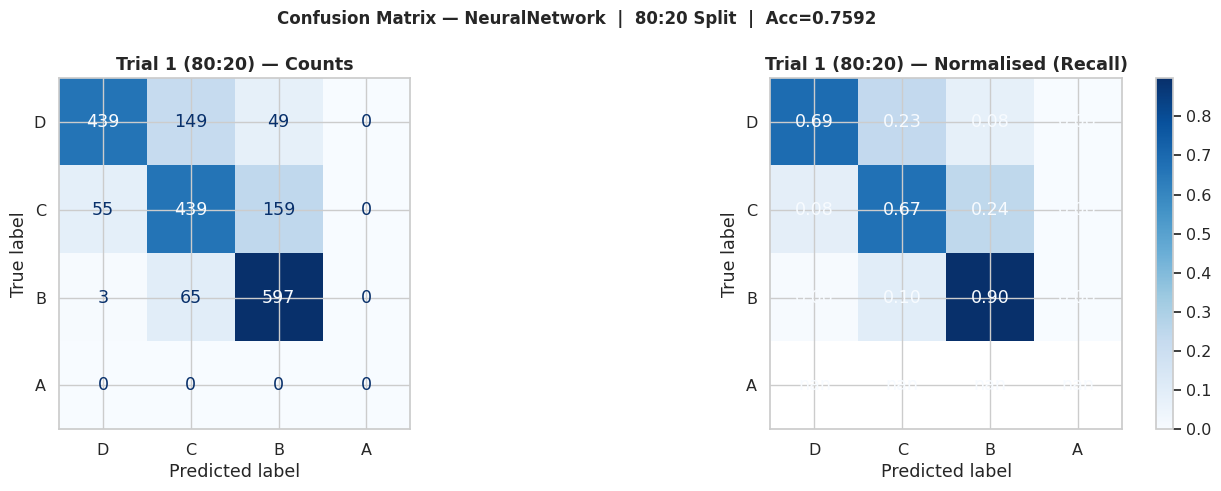

In [10]:
cm_1      = confusion_matrix(y_test_1, y_pred_best_1, labels=[1,2,3,4])
cm_1_norm  = cm_1.astype(float) / cm_1.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw counts
ConfusionMatrixDisplay(cm_1, display_labels=["D","C","B","A"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"Trial 1 (80:20) — Counts", fontweight="bold")

# Right: row-normalised (recall per class)
ConfusionMatrixDisplay(cm_1_norm, display_labels=["D","C","B","A"]).plot(
    ax=axes[1], cmap="Blues", colorbar=True, values_format=".2f")
axes[1].set_title(f"Trial 1 (80:20) — Normalised (Recall)", fontweight="bold")

plt.suptitle(
    f"Confusion Matrix — {best_t1['model']}  |  80:20 Split  |  Acc={best_t1['test_accuracy']:.4f}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


### Trial 1 — 5-Fold CV Score Verification

In [11]:
print(f"Trial 1 (80:20) — 5-Fold CV per Model:")
print(f"  {'Model':<16} {'F1':>7} {'F2':>7} {'F3':>7} {'F4':>7} {'F5':>7} {'Mean':>8} {'±Std':>7}")
print("  " + "─"*76)

for mname, model in models_t1.items():
    scores = cross_val_score(model, X_train_1, y_train_1,
                              cv=CV, scoring=SCORING, n_jobs=-1)
    print(f"  {mname:<16}" +
          "".join(f"{s:>7.4f}" for s in scores) +
          f"{scores.mean():>8.4f}{scores.std():>7.4f}")


Trial 1 (80:20) — 5-Fold CV per Model:
  Model                 F1      F2      F3      F4      F5     Mean    ±Std
  ────────────────────────────────────────────────────────────────────────────
  KNN              0.6397 0.6223 0.6312 0.6373 0.6355  0.6332 0.0061
  LogisticReg      0.6214 0.6176 0.6072 0.6105 0.6261  0.6166 0.0069
  DecisionTree     0.6609 0.6778 0.6689 0.6693 0.6787  0.6711 0.0066
  SVM              0.7258 0.7046 0.7027 0.7013 0.6999  0.7069 0.0096
  NeuralNetwork    0.7455 0.7375 0.7427 0.7230 0.7234  0.7344 0.0095
  RandomForest     0.7493 0.7310 0.7394 0.7244 0.7361  0.7360 0.0084


### Trial 1 — Save Trained Models

In [12]:
for mname, model in models_t1.items():
    fname = f"model_t1_{mname}.pkl"
    with open(fname, "wb") as f:
        pickle.dump(model, f)
    print(f"  Saved: {fname}")

# Save trial results to CSV
pd.DataFrame(results_t1).to_csv("cv_results_t1.csv", index=False)
print("\n✅ Trial 1 models and results saved.")


  Saved: model_t1_KNN.pkl
  Saved: model_t1_LogisticReg.pkl
  Saved: model_t1_DecisionTree.pkl
  Saved: model_t1_SVM.pkl
  Saved: model_t1_NeuralNetwork.pkl
  Saved: model_t1_RandomForest.pkl

✅ Trial 1 models and results saved.


---
# 🟡 Trial 2 — 70:30 Split  (70 % Train / 30 % Test)

**Purpose:** Train all 6 models on 70 % of the data and evaluate on the
remaining 30 %.

> ⚖️ Balanced trade-off between training size and test reliability.


## 📂 Trial 2 — Step 1: Create the 70:30 Split

In [13]:
# ── Create the 70:30 train/test split
# stratify=y ensures each class has the same proportion in both sets
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X, y,
    test_size   = 0.3,    # 30% test
    random_state= 42,             # fixed seed for reproducibility
    stratify    = y               # preserve class ratios
)

print(f"Trial 2 — 70:30 Split")
print(f"  Training rows : {X_train_2.shape[0]:,}  ({X_train_2.shape[0]/len(X)*100:.1f}%)")
print(f"  Test rows     : {X_test_2.shape[0]:,}  ({X_test_2.shape[0]/len(X)*100:.1f}%)")
print(f"  Features      : {X_train_2.shape[1]}")
print()
print("  Class distribution in training set:")
for cls, n in y_train_2.value_counts().sort_index().items():
    print(f"    class {cls}: {n:,}  ({n/len(y_train_2)*100:.1f}%)")

# Save splits
X_train_2.to_csv("X_train_t2.csv", index=False)
X_test_2.to_csv("X_test_t2.csv",   index=False)
y_train_2.to_csv("y_train_t2.csv", index=False)
y_test_2.to_csv("y_test_t2.csv",   index=False)
print("\n✅ Split CSVs saved (X_train_t2.csv, X_test_t2.csv, ...)")


Trial 2 — 70:30 Split
  Training rows : 9,301  (70.0%)
  Test rows     : 3,987  (30.0%)
  Features      : 12

  Class distribution in training set:
    class 0: 2,301  (24.7%)
    class 1: 2,336  (25.1%)
    class 2: 2,333  (25.1%)
    class 3: 2,331  (25.1%)

✅ Split CSVs saved (X_train_t2.csv, X_test_t2.csv, ...)


## 🤖 Trial 2 — Step 2: Train All 6 Models

In [14]:
print("="*60)
print(f"  TRIAL 2: 70:30 SPLIT — Training 6 Models")
print("="*60)
print(f"  {'Model':<16}  {'Best CV Acc':>12}  {'Time':>8}")
print("  " + "─"*42)

# ── Run RandomizedSearchCV for each model
knn_best_2,  knn_res_2  = train_model("KNN",          knn_pipe,  knn_params,  X_train_2, y_train_2)
lr_best_2,   lr_res_2   = train_model("LogisticReg",  lr_pipe,   lr_params,   X_train_2, y_train_2)
dt_best_2,   dt_res_2   = train_model("DecisionTree", dt_pipe,   dt_params,   X_train_2, y_train_2)
svm_best_2,  svm_res_2  = train_model("SVM",          svm_pipe,  svm_params,  X_train_2, y_train_2, n_iter=15)
mlp_best_2,  mlp_res_2  = train_model("NeuralNetwork",mlp_pipe,  mlp_params,  X_train_2, y_train_2)
rf_best_2,   rf_res_2   = train_model("RandomForest", rf_pipe,   rf_params,   X_train_2, y_train_2)

print("  " + "─"*42)
print("  ✅ All 6 models trained for Trial 2")


  TRIAL 2: 70:30 SPLIT — Training 6 Models
  Model              Best CV Acc      Time
  ──────────────────────────────────────────
  KNN               CV=0.6238  t=20.0s
  LogisticReg       CV=0.6192  t=13.6s
  DecisionTree      CV=0.6599  t=3.1s
  SVM               CV=0.6987  t=871.6s
  NeuralNetwork     CV=0.7312  t=429.2s
  RandomForest      CV=0.7309  t=458.8s
  ──────────────────────────────────────────
  ✅ All 6 models trained for Trial 2


## 📊 Trial 2 — Step 3: Test-Set Evaluation

In [15]:
# ── Collect all models for this trial
models_t2 = {
    "KNN"          : knn_best_2,
    "LogisticReg"  : lr_best_2,
    "DecisionTree" : dt_best_2,
    "SVM"          : svm_best_2,
    "NeuralNetwork": mlp_best_2,
    "RandomForest" : rf_best_2,
}

results_t2 = []
print(f"Trial 2 (70:30) — Test-Set Results:")
print(f"  {'Model':<16} {'CV Acc':>8} {'Test Acc':>10} {'F1 Mac':>8} {'F1 Wt':>8}")
print("  " + "─"*56)

for mname, model in models_t2.items():
    y_pred  = model.predict(X_test_2)
    cv_res  = [r for r in [knn_res_2, lr_res_2, dt_res_2,
                            svm_res_2, mlp_res_2, rf_res_2]
               if r["model"] == mname][0]
    test_acc = accuracy_score(y_test_2, y_pred)
    f1_mac   = f1_score(y_test_2, y_pred, average="macro",    zero_division=0)
    f1_wt    = f1_score(y_test_2, y_pred, average="weighted", zero_division=0)

    print(f"  {mname:<16} {cv_res['cv_accuracy']:>8.4f} {test_acc:>10.4f} {f1_mac:>8.4f} {f1_wt:>8.4f}")
    results_t2.append({
        "model"       : mname,
        "split"       : "70:30",
        "cv_accuracy" : cv_res["cv_accuracy"],
        "test_accuracy": test_acc,
        "f1_macro"    : f1_mac,
        "f1_weighted" : f1_wt,
        "best_params" : cv_res["best_params"],
    })

# Sort by test accuracy
results_t2 = sorted(results_t2, key=lambda x: x["test_accuracy"], reverse=True)
best_t2 = results_t2[0]
print()
print(f"  🏆 Best model (Trial 2) : {best_t2['model']}  →  Test Acc = {best_t2['test_accuracy']:.4f}")


Trial 2 (70:30) — Test-Set Results:
  Model              CV Acc   Test Acc   F1 Mac    F1 Wt
  ────────────────────────────────────────────────────────
  KNN                0.6238     0.6396   0.6410   0.6406
  LogisticReg        0.6192     0.6173   0.6145   0.6140
  DecisionTree       0.6599     0.6850   0.6863   0.6858
  SVM                0.6987     0.7111   0.7102   0.7097
  NeuralNetwork      0.7312     0.7459   0.7465   0.7461
  RandomForest       0.7309     0.7447   0.7456   0.7452

  🏆 Best model (Trial 2) : NeuralNetwork  →  Test Acc = 0.7459


### Trial 2 — Detailed Classification Report (Best Model)

In [16]:
# Full per-class breakdown for the best model in this trial
best_model_t2 = models_t2[best_t2["model"]]
y_pred_best_2 = best_model_t2.predict(X_test_2)

print(f"Classification Report — {best_t2['model']}  (70:30 split)")
print(classification_report(
    y_test_2, y_pred_best_2,
    target_names=["Class 1 (D-Worst)", "Class 2 (C)", "Class 3 (B)", "Class 4 (A-Best)"],
    zero_division=0
))


Classification Report — NeuralNetwork  (70:30 split)
                   precision    recall  f1-score   support

Class 1 (D-Worst)       0.96      0.77      0.85       986
      Class 2 (C)       0.73      0.68      0.70      1001
      Class 3 (B)       0.64      0.62      0.63      1000
 Class 4 (A-Best)       0.71      0.91      0.80      1000

         accuracy                           0.75      3987
        macro avg       0.76      0.75      0.75      3987
     weighted avg       0.76      0.75      0.75      3987



### Trial 2 — Confusion Matrix (Best Model)

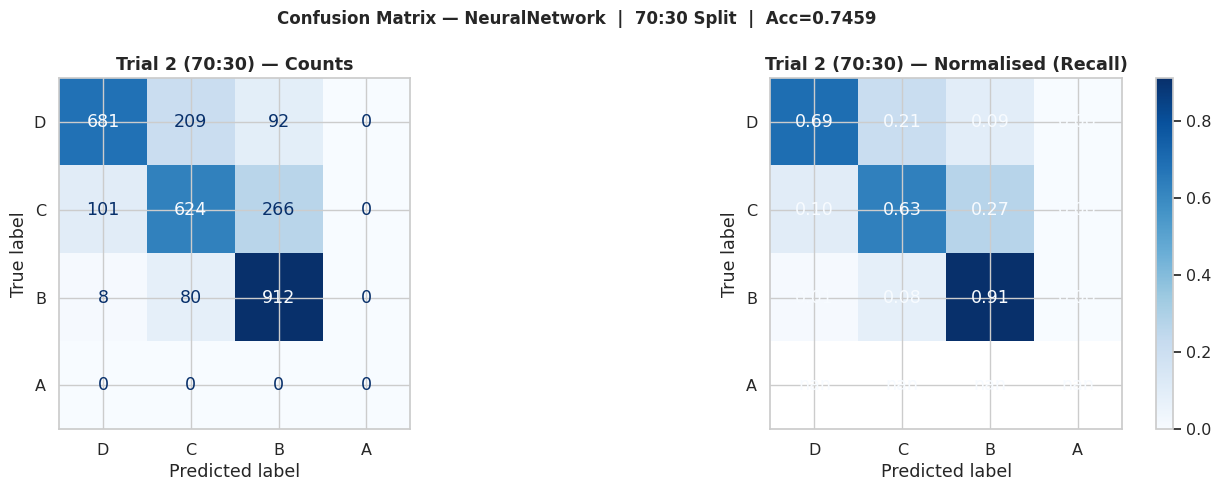

In [17]:
cm_2      = confusion_matrix(y_test_2, y_pred_best_2, labels=[1,2,3,4])
cm_2_norm  = cm_2.astype(float) / cm_2.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw counts
ConfusionMatrixDisplay(cm_2, display_labels=["D","C","B","A"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"Trial 2 (70:30) — Counts", fontweight="bold")

# Right: row-normalised (recall per class)
ConfusionMatrixDisplay(cm_2_norm, display_labels=["D","C","B","A"]).plot(
    ax=axes[1], cmap="Blues", colorbar=True, values_format=".2f")
axes[1].set_title(f"Trial 2 (70:30) — Normalised (Recall)", fontweight="bold")

plt.suptitle(
    f"Confusion Matrix — {best_t2['model']}  |  70:30 Split  |  Acc={best_t2['test_accuracy']:.4f}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


### Trial 2 — 5-Fold CV Score Verification

In [18]:
print(f"Trial 2 (70:30) — 5-Fold CV per Model:")
print(f"  {'Model':<16} {'F1':>7} {'F2':>7} {'F3':>7} {'F4':>7} {'F5':>7} {'Mean':>8} {'±Std':>7}")
print("  " + "─"*76)

for mname, model in models_t2.items():
    scores = cross_val_score(model, X_train_2, y_train_2,
                              cv=CV, scoring=SCORING, n_jobs=-1)
    print(f"  {mname:<16}" +
          "".join(f"{s:>7.4f}" for s in scores) +
          f"{scores.mean():>8.4f}{scores.std():>7.4f}")


Trial 2 (70:30) — 5-Fold CV per Model:
  Model                 F1      F2      F3      F4      F5     Mean    ±Std
  ────────────────────────────────────────────────────────────────────────────
  KNN              0.6179 0.6156 0.6204 0.6554 0.6097  0.6238 0.0162
  LogisticReg      0.6153 0.6151 0.6102 0.6323 0.6231  0.6192 0.0077
  DecisionTree     0.6599 0.6667 0.6457 0.6591 0.6683  0.6599 0.0080
  SVM              0.7007 0.6887 0.6984 0.7129 0.6930  0.6987 0.0082
  NeuralNetwork    0.7147 0.7312 0.7296 0.7430 0.7376  0.7312 0.0096
  RandomForest     0.7168 0.7387 0.7156 0.7522 0.7312  0.7309 0.0137


### Trial 2 — Save Trained Models

In [19]:
for mname, model in models_t2.items():
    fname = f"model_t2_{mname}.pkl"
    with open(fname, "wb") as f:
        pickle.dump(model, f)
    print(f"  Saved: {fname}")

# Save trial results to CSV
pd.DataFrame(results_t2).to_csv("cv_results_t2.csv", index=False)
print("\n✅ Trial 2 models and results saved.")


  Saved: model_t2_KNN.pkl
  Saved: model_t2_LogisticReg.pkl
  Saved: model_t2_DecisionTree.pkl
  Saved: model_t2_SVM.pkl
  Saved: model_t2_NeuralNetwork.pkl
  Saved: model_t2_RandomForest.pkl

✅ Trial 2 models and results saved.


---
# 🔴 Trial 3 — 50:50 Split  (50 % Train / 50 % Test)

**Purpose:** Train all 6 models on 50 % of the data and evaluate on the
remaining 50 %.

> ⚠️ Equal train/test — tests how models perform with less training data.


## 📂 Trial 3 — Step 1: Create the 50:50 Split

In [20]:
# ── Create the 50:50 train/test split
# stratify=y ensures each class has the same proportion in both sets
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X, y,
    test_size   = 0.5,    # 50% test
    random_state= 42,             # fixed seed for reproducibility
    stratify    = y               # preserve class ratios
)

print(f"Trial 3 — 50:50 Split")
print(f"  Training rows : {X_train_3.shape[0]:,}  ({X_train_3.shape[0]/len(X)*100:.1f}%)")
print(f"  Test rows     : {X_test_3.shape[0]:,}  ({X_test_3.shape[0]/len(X)*100:.1f}%)")
print(f"  Features      : {X_train_3.shape[1]}")
print()
print("  Class distribution in training set:")
for cls, n in y_train_3.value_counts().sort_index().items():
    print(f"    class {cls}: {n:,}  ({n/len(y_train_3)*100:.1f}%)")

# Save splits
X_train_3.to_csv("X_train_t3.csv", index=False)
X_test_3.to_csv("X_test_t3.csv",   index=False)
y_train_3.to_csv("y_train_t3.csv", index=False)
y_test_3.to_csv("y_test_t3.csv",   index=False)
print("\n✅ Split CSVs saved (X_train_t3.csv, X_test_t3.csv, ...)")


Trial 3 — 50:50 Split
  Training rows : 6,644  (50.0%)
  Test rows     : 6,644  (50.0%)
  Features      : 12

  Class distribution in training set:
    class 0: 1,644  (24.7%)
    class 1: 1,669  (25.1%)
    class 2: 1,666  (25.1%)
    class 3: 1,665  (25.1%)

✅ Split CSVs saved (X_train_t3.csv, X_test_t3.csv, ...)


## 🤖 Trial 3 — Step 2: Train All 6 Models

In [21]:
print("="*60)
print(f"  TRIAL 3: 50:50 SPLIT — Training 6 Models")
print("="*60)
print(f"  {'Model':<16}  {'Best CV Acc':>12}  {'Time':>8}")
print("  " + "─"*42)

# ── Run RandomizedSearchCV for each model
knn_best_3,  knn_res_3  = train_model("KNN",          knn_pipe,  knn_params,  X_train_3, y_train_3)
lr_best_3,   lr_res_3   = train_model("LogisticReg",  lr_pipe,   lr_params,   X_train_3, y_train_3)
dt_best_3,   dt_res_3   = train_model("DecisionTree", dt_pipe,   dt_params,   X_train_3, y_train_3)
svm_best_3,  svm_res_3  = train_model("SVM",          svm_pipe,  svm_params,  X_train_3, y_train_3, n_iter=15)
mlp_best_3,  mlp_res_3  = train_model("NeuralNetwork",mlp_pipe,  mlp_params,  X_train_3, y_train_3)
rf_best_3,   rf_res_3   = train_model("RandomForest", rf_pipe,   rf_params,   X_train_3, y_train_3)

print("  " + "─"*42)
print("  ✅ All 6 models trained for Trial 3")


  TRIAL 3: 50:50 SPLIT — Training 6 Models
  Model              Best CV Acc      Time
  ──────────────────────────────────────────
  KNN               CV=0.6136  t=12.6s
  LogisticReg       CV=0.6169  t=11.4s
  DecisionTree      CV=0.6388  t=2.0s
  SVM               CV=0.6892  t=437.6s
  NeuralNetwork     CV=0.7203  t=263.4s
  RandomForest      CV=0.7149  t=343.7s
  ──────────────────────────────────────────
  ✅ All 6 models trained for Trial 3


## 📊 Trial 3 — Step 3: Test-Set Evaluation

In [22]:
# ── Collect all models for this trial
models_t3 = {
    "KNN"          : knn_best_3,
    "LogisticReg"  : lr_best_3,
    "DecisionTree" : dt_best_3,
    "SVM"          : svm_best_3,
    "NeuralNetwork": mlp_best_3,
    "RandomForest" : rf_best_3,
}

results_t3 = []
print(f"Trial 3 (50:50) — Test-Set Results:")
print(f"  {'Model':<16} {'CV Acc':>8} {'Test Acc':>10} {'F1 Mac':>8} {'F1 Wt':>8}")
print("  " + "─"*56)

for mname, model in models_t3.items():
    y_pred  = model.predict(X_test_3)
    cv_res  = [r for r in [knn_res_3, lr_res_3, dt_res_3,
                            svm_res_3, mlp_res_3, rf_res_3]
               if r["model"] == mname][0]
    test_acc = accuracy_score(y_test_3, y_pred)
    f1_mac   = f1_score(y_test_3, y_pred, average="macro",    zero_division=0)
    f1_wt    = f1_score(y_test_3, y_pred, average="weighted", zero_division=0)

    print(f"  {mname:<16} {cv_res['cv_accuracy']:>8.4f} {test_acc:>10.4f} {f1_mac:>8.4f} {f1_wt:>8.4f}")
    results_t3.append({
        "model"       : mname,
        "split"       : "50:50",
        "cv_accuracy" : cv_res["cv_accuracy"],
        "test_accuracy": test_acc,
        "f1_macro"    : f1_mac,
        "f1_weighted" : f1_wt,
        "best_params" : cv_res["best_params"],
    })

# Sort by test accuracy
results_t3 = sorted(results_t3, key=lambda x: x["test_accuracy"], reverse=True)
best_t3 = results_t3[0]
print()
print(f"  🏆 Best model (Trial 3) : {best_t3['model']}  →  Test Acc = {best_t3['test_accuracy']:.4f}")


Trial 3 (50:50) — Test-Set Results:
  Model              CV Acc   Test Acc   F1 Mac    F1 Wt
  ────────────────────────────────────────────────────────
  KNN                0.6136     0.6248   0.6259   0.6254
  LogisticReg        0.6169     0.6186   0.6166   0.6160
  DecisionTree       0.6388     0.6454   0.6485   0.6480
  SVM                0.6892     0.7002   0.7003   0.6998
  NeuralNetwork      0.7203     0.7371   0.7374   0.7369
  RandomForest       0.7149     0.7228   0.7227   0.7222

  🏆 Best model (Trial 3) : NeuralNetwork  →  Test Acc = 0.7371


### Trial 3 — Detailed Classification Report (Best Model)

In [23]:
# Full per-class breakdown for the best model in this trial
best_model_t3 = models_t3[best_t3["model"]]
y_pred_best_3 = best_model_t3.predict(X_test_3)

print(f"Classification Report — {best_t3['model']}  (50:50 split)")
print(classification_report(
    y_test_3, y_pred_best_3,
    target_names=["Class 1 (D-Worst)", "Class 2 (C)", "Class 3 (B)", "Class 4 (A-Best)"],
    zero_division=0
))


Classification Report — NeuralNetwork  (50:50 split)
                   precision    recall  f1-score   support

Class 1 (D-Worst)       0.90      0.83      0.87      1643
      Class 2 (C)       0.75      0.62      0.68      1668
      Class 3 (B)       0.60      0.64      0.62      1667
 Class 4 (A-Best)       0.72      0.86      0.78      1666

         accuracy                           0.74      6644
        macro avg       0.74      0.74      0.74      6644
     weighted avg       0.74      0.74      0.74      6644



### Trial 3 — Confusion Matrix (Best Model)

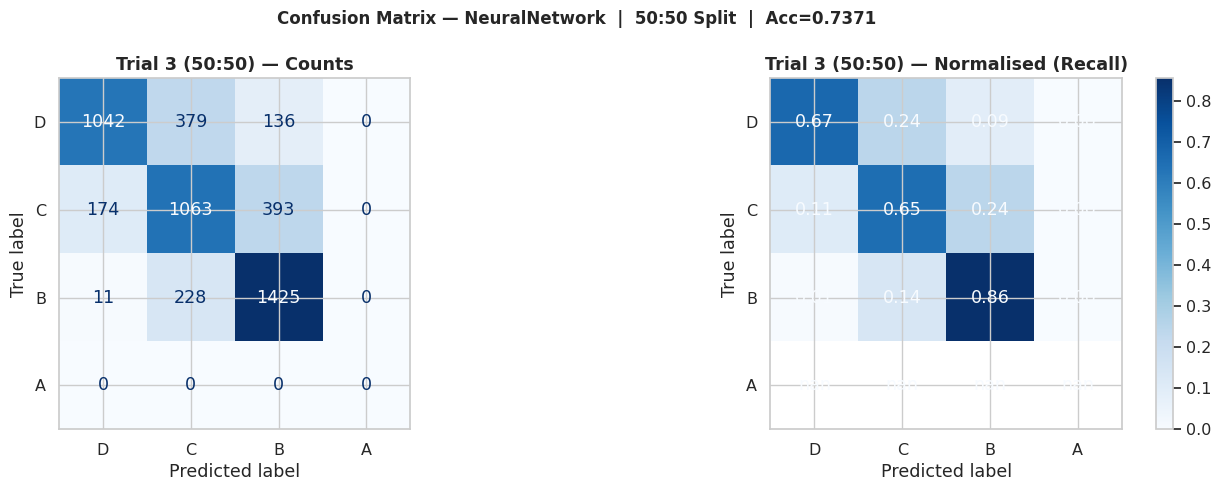

In [24]:
cm_3      = confusion_matrix(y_test_3, y_pred_best_3, labels=[1,2,3,4])
cm_3_norm  = cm_3.astype(float) / cm_3.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw counts
ConfusionMatrixDisplay(cm_3, display_labels=["D","C","B","A"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"Trial 3 (50:50) — Counts", fontweight="bold")

# Right: row-normalised (recall per class)
ConfusionMatrixDisplay(cm_3_norm, display_labels=["D","C","B","A"]).plot(
    ax=axes[1], cmap="Blues", colorbar=True, values_format=".2f")
axes[1].set_title(f"Trial 3 (50:50) — Normalised (Recall)", fontweight="bold")

plt.suptitle(
    f"Confusion Matrix — {best_t3['model']}  |  50:50 Split  |  Acc={best_t3['test_accuracy']:.4f}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


### Trial 3 — 5-Fold CV Score Verification

In [25]:
print(f"Trial 3 (50:50) — 5-Fold CV per Model:")
print(f"  {'Model':<16} {'F1':>7} {'F2':>7} {'F3':>7} {'F4':>7} {'F5':>7} {'Mean':>8} {'±Std':>7}")
print("  " + "─"*76)

for mname, model in models_t3.items():
    scores = cross_val_score(model, X_train_3, y_train_3,
                              cv=CV, scoring=SCORING, n_jobs=-1)
    print(f"  {mname:<16}" +
          "".join(f"{s:>7.4f}" for s in scores) +
          f"{scores.mean():>8.4f}{scores.std():>7.4f}")


Trial 3 (50:50) — 5-Fold CV per Model:
  Model                 F1      F2      F3      F4      F5     Mean    ±Std
  ────────────────────────────────────────────────────────────────────────────
  KNN              0.5847 0.6351 0.6057 0.6178 0.6250  0.6136 0.0174
  LogisticReg      0.6050 0.6215 0.6321 0.6117 0.6145  0.6169 0.0092
  DecisionTree     0.6283 0.6388 0.6253 0.6448 0.6566  0.6388 0.0114
  SVM              0.6810 0.6983 0.6885 0.6907 0.6875  0.6892 0.0056
  NeuralNetwork    0.7223 0.7329 0.7276 0.7111 0.7078  0.7203 0.0096
  RandomForest     0.7013 0.7404 0.6885 0.7088 0.7357  0.7149 0.0200


### Trial 3 — Save Trained Models

In [26]:
for mname, model in models_t3.items():
    fname = f"model_t3_{mname}.pkl"
    with open(fname, "wb") as f:
        pickle.dump(model, f)
    print(f"  Saved: {fname}")

# Save trial results to CSV
pd.DataFrame(results_t3).to_csv("cv_results_t3.csv", index=False)
print("\n✅ Trial 3 models and results saved.")


  Saved: model_t3_KNN.pkl
  Saved: model_t3_LogisticReg.pkl
  Saved: model_t3_DecisionTree.pkl
  Saved: model_t3_SVM.pkl
  Saved: model_t3_NeuralNetwork.pkl
  Saved: model_t3_RandomForest.pkl

✅ Trial 3 models and results saved.


---
# 📊 Section 5 — Cross-Trial Comparison (All 3 Splits)

**Objective:** Compare every model's test accuracy across the three split ratios
to understand:
1. Which models are most data-hungry (big drop from 80:20 → 50:50)
2. Which models generalise well even with less training data
3. The overall best model + split combination


## 📋 Step 1 — Consolidated Results Table

In [27]:
# Merge results from all 3 trials
all_results = results_t1 + results_t2 + results_t3
all_df = pd.DataFrame(all_results)

# Pivot: model as rows, split as columns (test accuracy)
pivot = all_df.pivot_table(
    index="model", columns="split",
    values="test_accuracy", aggfunc="first"
)
# Add rank column for the best split per model
pivot["Best Split"] = pivot.idxmax(axis=1)
pivot["Best Acc"]   = pivot[["80:20","70:30","50:50"]].max(axis=1)
pivot = pivot.sort_values("Best Acc", ascending=False)

print("Test Accuracy by Model and Split Ratio:")
print(pivot.round(4).to_string())

print()
print("Overall Best Combination:")
best_row = all_df.loc[all_df["test_accuracy"].idxmax()]
print(f"  Model : {best_row['model']}")
print(f"  Split : {best_row['split']}")
print(f"  Test Accuracy : {best_row['test_accuracy']:.4f}")
print(f"  Macro F1      : {best_row['f1_macro']:.4f}")


Test Accuracy by Model and Split Ratio:
split           50:50   70:30   80:20 Best Split  Best Acc
model                                                     
NeuralNetwork  0.7371  0.7459  0.7592      80:20    0.7592
RandomForest   0.7228  0.7447  0.7532      80:20    0.7532
SVM            0.7002  0.7111  0.7193      80:20    0.7193
DecisionTree   0.6454  0.6850  0.6806      70:30    0.6850
KNN            0.6248  0.6396  0.6381      70:30    0.6396
LogisticReg    0.6186  0.6173  0.6204      80:20    0.6204

Overall Best Combination:
  Model : NeuralNetwork
  Split : 80:20
  Test Accuracy : 0.7592
  Macro F1      : 0.7592


## 📊 Step 2 — Grouped Bar Chart (Test Accuracy per Split)

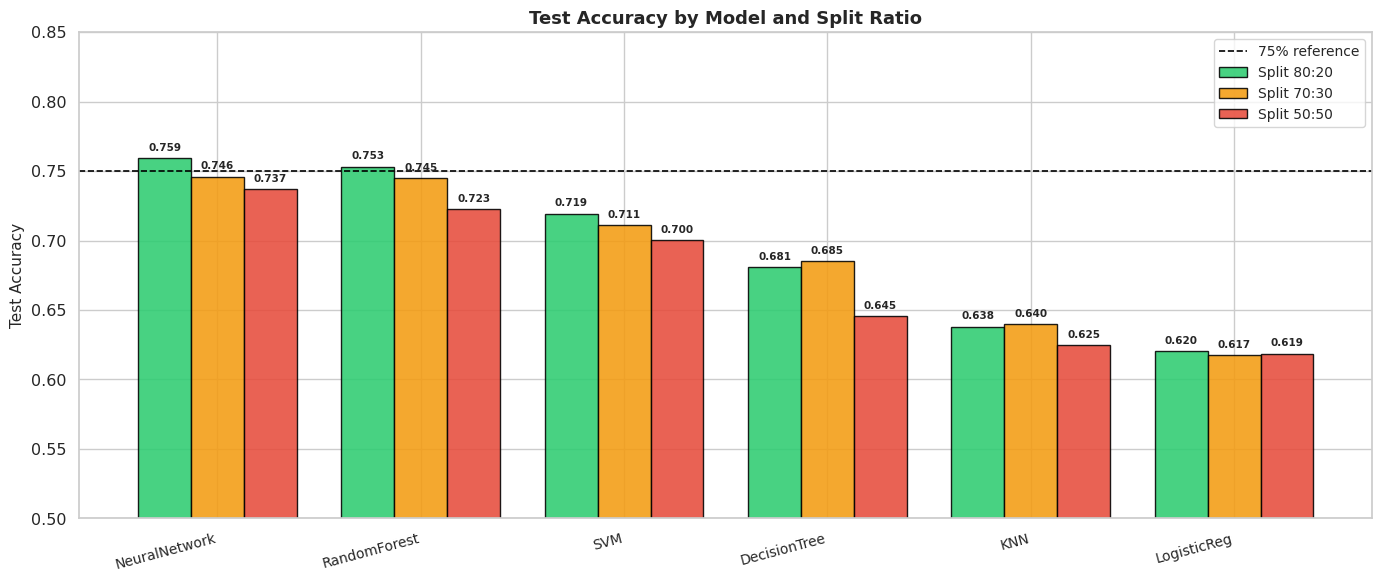

In [28]:
model_order = pivot.index.tolist()
splits      = ["80:20", "70:30", "50:50"]
split_colors= ["#2ecc71", "#f39c12", "#e74c3c"]
x = np.arange(len(model_order))
width = 0.26

fig, ax = plt.subplots(figsize=(14, 6))
for i, (split, color) in enumerate(zip(splits, split_colors)):
    vals  = [pivot.loc[m, split] if split in pivot.columns else 0
             for m in model_order]
    bars  = ax.bar(x + i*width, vals, width,
                   label=f"Split {split}", color=color,
                   edgecolor="black", alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(model_order, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0.5, 0.85)
ax.set_ylabel("Test Accuracy", fontsize=11)
ax.set_title("Test Accuracy by Model and Split Ratio",
             fontsize=13, fontweight="bold")
ax.axhline(0.75, color="black", linestyle="--", lw=1.2, label="75% reference")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 📉 Step 3 — Accuracy Drop Chart (80:20 → 50:50)

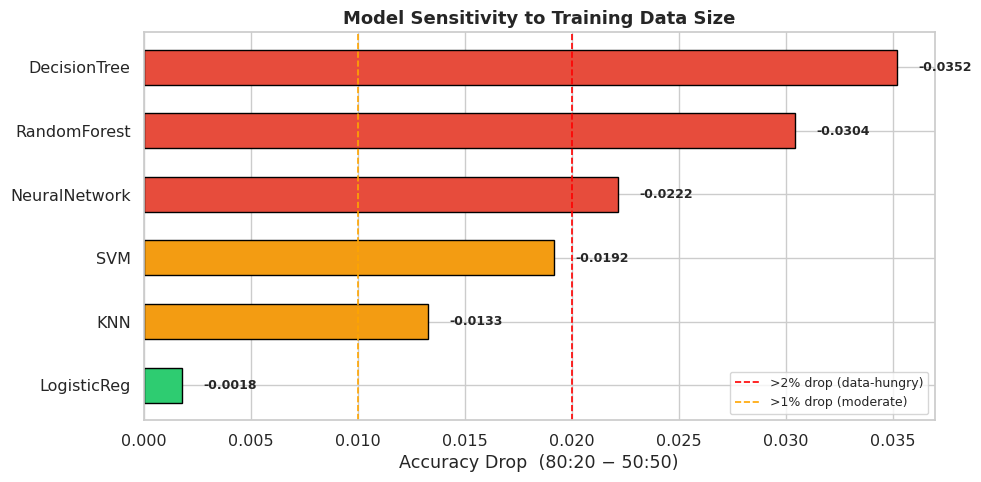


Data-Hunger Summary:
        Model    80:20    50:50     Drop
 DecisionTree 0.680587 0.645394 0.035193
 RandomForest 0.753198 0.722757 0.030441
NeuralNetwork 0.759217 0.737056 0.022161
          SVM 0.719338 0.700181 0.019157
          KNN 0.638074 0.624774 0.013300
  LogisticReg 0.620391 0.618603 0.001788


In [29]:
# How much does each model lose going from max to min training data?
drops = []
for model in model_order:
    acc_80 = pivot.loc[model, "80:20"]
    acc_50 = pivot.loc[model, "50:50"]
    drops.append({"Model": model, "80:20": acc_80, "50:50": acc_50,
                  "Drop": acc_80 - acc_50})

drop_df = pd.DataFrame(drops).sort_values("Drop", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ["#e74c3c" if d > 0.02 else "#f39c12" if d > 0.01 else "#2ecc71"
           for d in drop_df["Drop"]]
bars = ax.barh(drop_df["Model"][::-1], drop_df["Drop"][::-1],
               color=colors[::-1], edgecolor="black", height=0.55)
for bar, val in zip(bars, drop_df["Drop"][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"-{val:.4f}", va="center", fontsize=9, fontweight="bold")
ax.axvline(0.02, color="red",    linestyle="--", lw=1.2, label=">2% drop (data-hungry)")
ax.axvline(0.01, color="orange", linestyle="--", lw=1.2, label=">1% drop (moderate)")
ax.set_xlabel("Accuracy Drop  (80:20 − 50:50)")
ax.set_title("Model Sensitivity to Training Data Size",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nData-Hunger Summary:")
print(drop_df[["Model","80:20","50:50","Drop"]].to_string(index=False))


## 🕸️ Step 4 — Radar Chart (Best Model per Split)

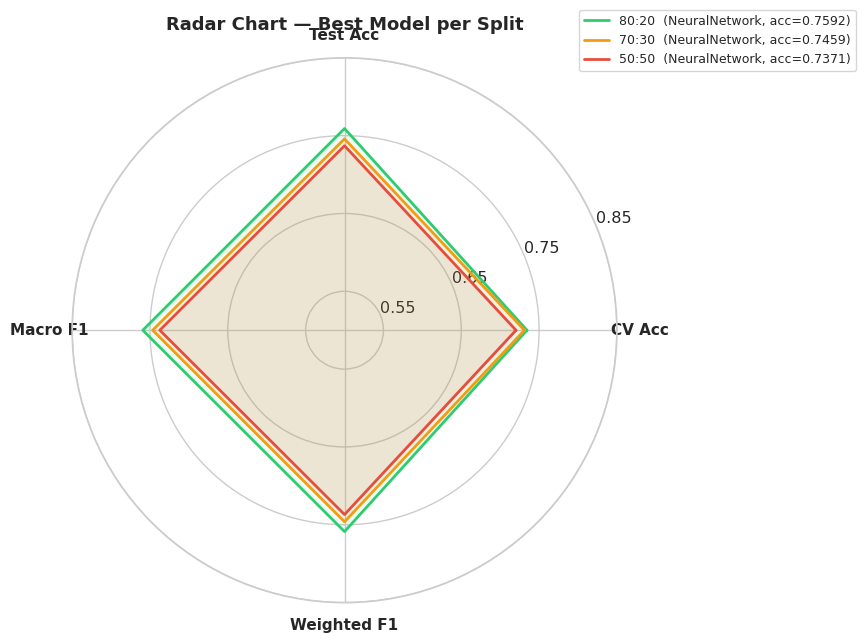

In [30]:
# Compare the best model in each split across 4 metrics
metrics = ["cv_accuracy", "test_accuracy", "f1_macro", "f1_weighted"]
metric_labels = ["CV Acc", "Test Acc", "Macro F1", "Weighted F1"]

n_metrics = len(metrics)
angles    = [n / n_metrics * 2 * np.pi for n in range(n_metrics)]
angles   += angles[:1]

best_per_split = {}
for split in ["80:20", "70:30", "50:50"]:
    sub = all_df[all_df["split"] == split]
    best_per_split[split] = sub.loc[sub["test_accuracy"].idxmax()]

fig = plt.figure(figsize=(8, 7))
ax  = fig.add_subplot(111, polar=True)
colors_radar = ["#2ecc71", "#f39c12", "#e74c3c"]

for (split, row), color in zip(best_per_split.items(), colors_radar):
    vals   = [row[m] for m in metrics] + [row[metrics[0]]]
    label  = f"{split}  ({row['model']}, acc={row['test_accuracy']:.4f})"
    ax.plot(angles, vals, lw=2, label=label, color=color)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, size=11, fontweight="bold")
ax.set_ylim(0.5, 0.85)
ax.set_yticks([0.55, 0.65, 0.75, 0.85])
ax.set_title("Radar Chart — Best Model per Split",
             fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.1), fontsize=9)
plt.tight_layout()
plt.show()


## 💾 Step 5 — Save All Results & Summary

In [31]:
# Save combined results
all_df.to_csv("cv_results.csv", index=False)
print("✅ Saved: cv_results.csv  (all 3 trials, all 6 models)")

# Print final leaderboard
print()
print("═"*65)
print("  FINAL LEADERBOARD — ALL TRIALS")
print("═"*65)
print(f"  {'Rank':<5} {'Model':<16} {'Split':<8} {'Test Acc':>10} {'Macro F1':>10}")
print("  " + "─"*52)
for rank, (_, row) in enumerate(
        all_df.sort_values("test_accuracy", ascending=False).iterrows(), 1):
    flag = "  ← 🏆 BEST" if rank == 1 else ""
    print(f"  {rank:<5} {row['model']:<16} {row['split']:<8} "          f"{row['test_accuracy']:>10.4f} {row['f1_macro']:>10.4f}{flag}")
    if rank >= 10:
        print("  ..."); break

print()
print("✅ All models saved. Proceed to 05_Evaluation.ipynb")


✅ Saved: cv_results.csv  (all 3 trials, all 6 models)

═════════════════════════════════════════════════════════════════
  FINAL LEADERBOARD — ALL TRIALS
═════════════════════════════════════════════════════════════════
  Rank  Model            Split      Test Acc   Macro F1
  ────────────────────────────────────────────────────
  1     NeuralNetwork    80:20        0.7592     0.7592  ← 🏆 BEST
  2     RandomForest     80:20        0.7532     0.7547
  3     NeuralNetwork    70:30        0.7459     0.7465
  4     RandomForest     70:30        0.7447     0.7456
  5     NeuralNetwork    50:50        0.7371     0.7374
  6     RandomForest     50:50        0.7228     0.7227
  7     SVM              80:20        0.7193     0.7189
  8     SVM              70:30        0.7111     0.7102
  9     SVM              50:50        0.7002     0.7003
  10    DecisionTree     70:30        0.6850     0.6863
  ...

✅ All models saved. Proceed to 05_Evaluation.ipynb
